In [110]:
import torch
import torch.nn as nn
import pickle
import numpy as np
import torchvision
from torchvision.models import vgg11, ResNet50_Weights, resnet50
import matplotlib.pyplot as plt
from torch.utils.flop_counter import FlopCounterMode
from typing import Union, Tuple
import os
from mpl_toolkits import axes_grid1
import plotly.graph_objects as go
import plotly.colors as pc
from utils import is_cnn_layer
import pickle

In [114]:
dataset = "cifar100"
model_name = "vgg11"
num_epochs = 200
experiment = "mambafrz_vgg11_MambaFRZ_validation_test_7_30"
experiment_name = "MambaFRZ 20 Conv 25 Seeds"
experiment_seed = 1527
experiment_device = "cuda:0"
predictor_type = "MambaFRZ"

In [115]:
def plot_accuracy_of_full_vs_similarity_guided_training_metrics(full_training_file, similarity_guided_training_file):
    with open(full_training_file, 'rb') as f:
        full_training = pickle.load(f)
    with open(similarity_guided_training_file, 'rb') as f:
        similarity_guided_training = pickle.load(f)

    acc_full, train_loss_full, test_loss_full = full_training
    acc_sim, train_loss_sim, test_loss_sim = similarity_guided_training

    epochs = list(range(1, len(acc_full) + 1))

    for index, (acc1, acc2) in enumerate(zip(acc_full, acc_sim)):
        acc_full[index] = acc1 * 100.0
        acc_sim[index] = acc2 * 100.0
    print(f"Max Accuracy Full Training: {max(acc_full)}")
    print(f"Max Accuracy Similarity-Guided Training: {max(acc_sim)}")
    # Plot Accuracy
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, acc_full, label='End-to-End Accuracy')
    plt.plot(epochs, acc_sim, label='Similarity-Guided Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Training Loss
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_loss_full, label='End-to-End Training Loss')
    plt.plot(epochs, train_loss_sim, label='Similarity-Guided Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Validation Loss
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_loss_full, label='End-to-End Validation Loss')
    plt.plot(epochs, train_loss_sim, label='Similarity-Guided Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

Max Accuracy Full Training: 61.47
Max Accuracy Similarity-Guided Training: 61.47


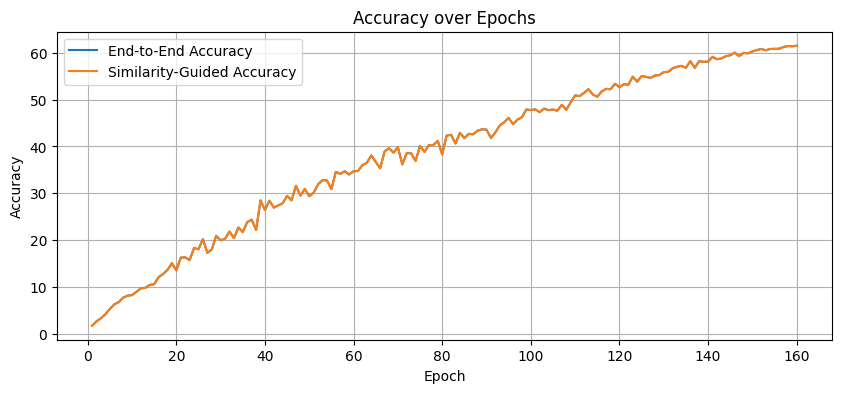

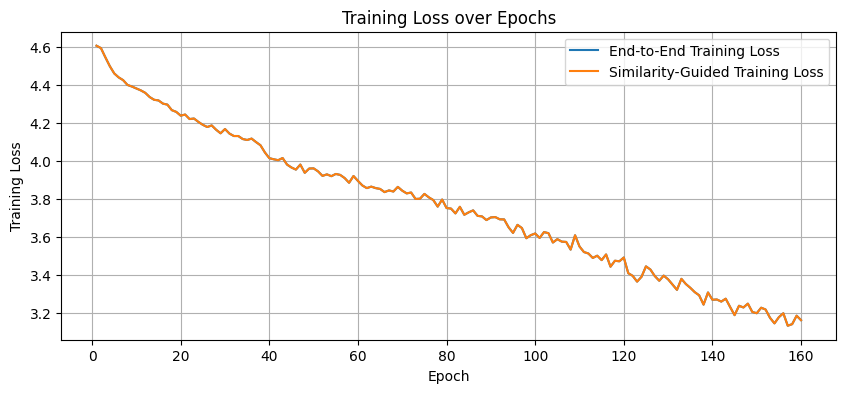

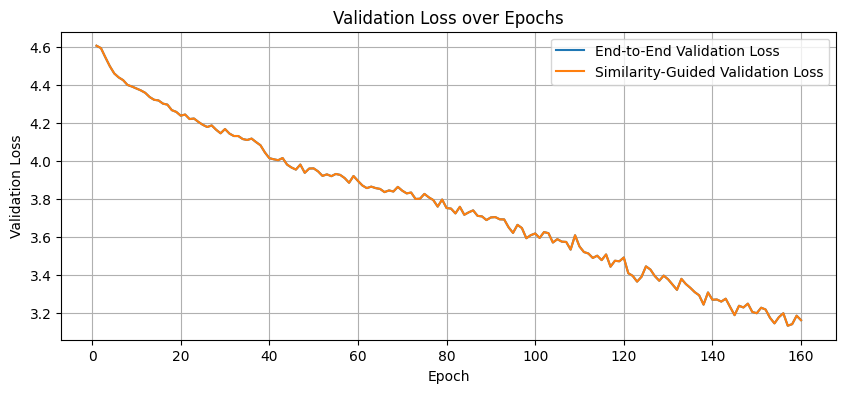

In [116]:
seed_test_1 = experiment_seed
seed_test_2 = experiment_seed
plot_accuracy_of_full_vs_similarity_guided_training_metrics(os.path.join(experiment, f"seed_{seed_test_1}", f"fully_trained_reference_model_{model_name}_metrics.pkl"), os.path.join(experiment, f"seed_{seed_test_2}", f"fully_trained_reference_model_{model_name}_metrics.pkl"))

In [117]:
# Compare CKA values of experiment with failed weights and new weights
def plot_results_plotly(all_epochs_matrix, layer_types='s'):
    # Convert PyTorch tensor to NumPy if needed
    if isinstance(all_epochs_matrix, torch.Tensor):
        all_epochs_matrix = all_epochs_matrix.cpu().numpy()

    num_rows, num_cols = all_epochs_matrix.shape
    time_steps = np.arange(num_rows)

    fig = go.Figure()

    colors = pc.qualitative.Plotly  # You can change this to any color scale

    if layer_types == 's':
        for i in range(8):
            color = colors[i % len(colors)]  # Cycle through colors
            fig.add_trace(go.Scatter(
                x=time_steps, y=all_epochs_matrix[:, i], mode='lines',
                line=dict(color=color),  # Set line color
                name=f"{i+1}"
            ))
            plt.plot(time_steps, all_epochs_matrix[:, i], label=f"{i+1}")
    plt.title("CKA values over time")
    plt.legend()
    plt.show()

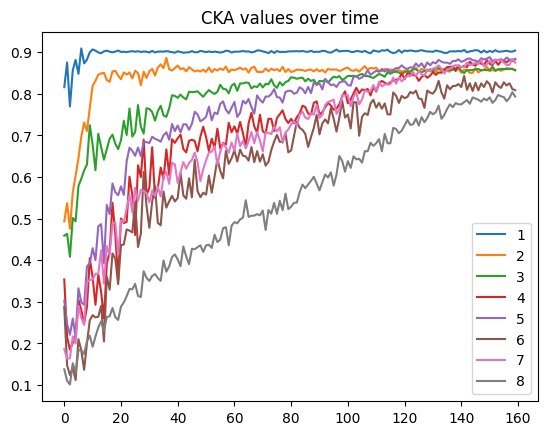

In [118]:
# Generation of CKA matrix for post-processing
cka_over_time_file = f"{experiment}/seed_{experiment_seed}/vgg11_cka_values_across_epochs.pkl"
with open(cka_over_time_file, "rb") as f:
    cka_over_time = pickle.load(f)
    list_of_layers = list(cka_over_time.keys())
    max_epochs = max(len(cka_over_time[key]) for key in list(cka_over_time.keys()))
    max_layers = len(list_of_layers)
    cka_matrix = torch.zeros((max_layers, max_epochs))
    for layer_index, layer in enumerate(list_of_layers):
      max_epochs_trained_for_layer = len(cka_over_time[layer])
      for epoch in range(max_epochs_trained_for_layer):
          cka_matrix[layer_index][epoch] = cka_over_time[layer][epoch]
    all_epochs_matrix = cka_matrix.T
plot_results_plotly(all_epochs_matrix)

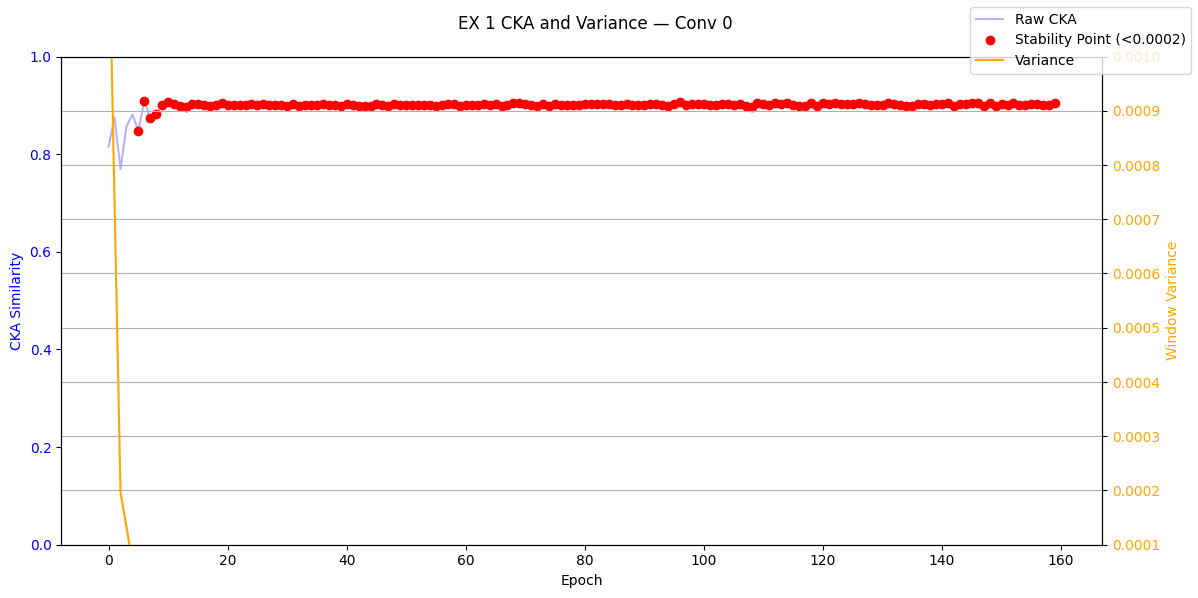

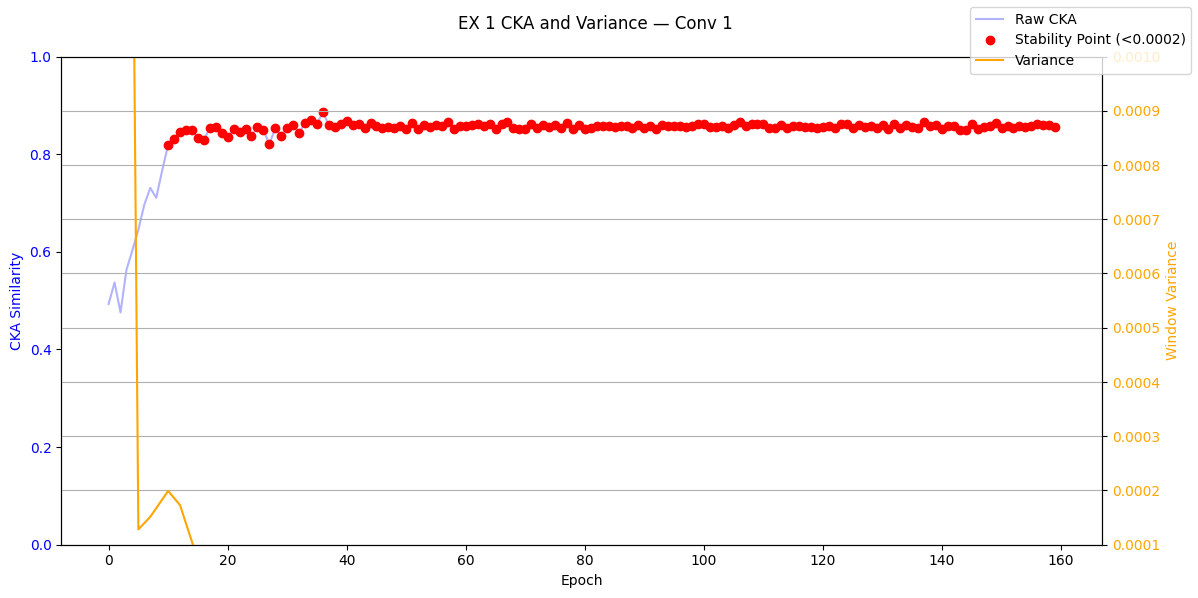

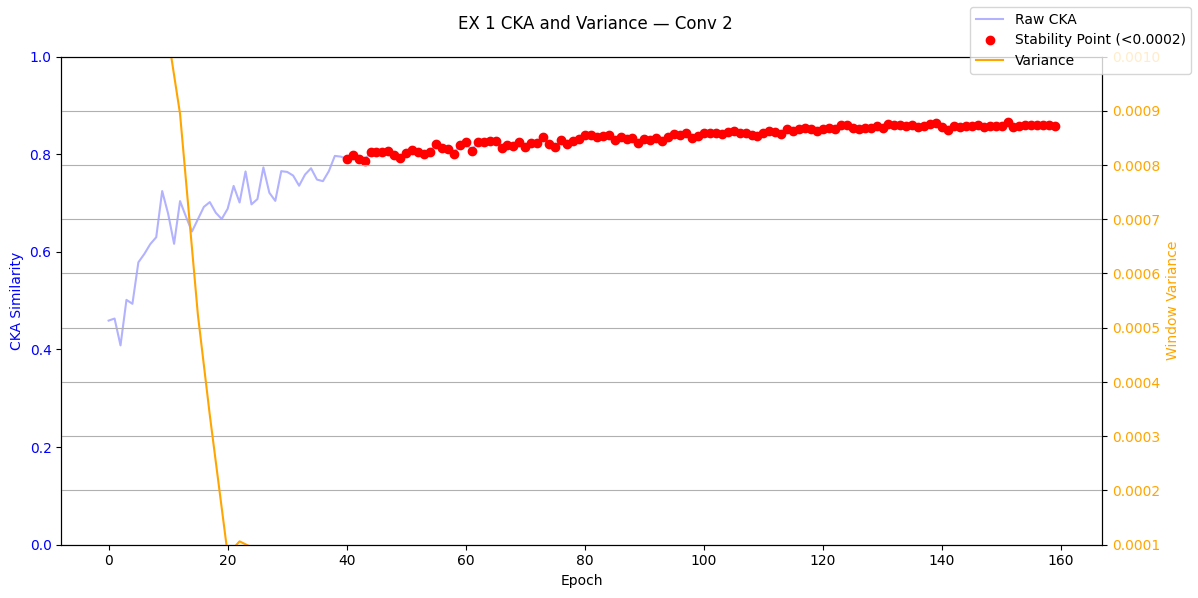

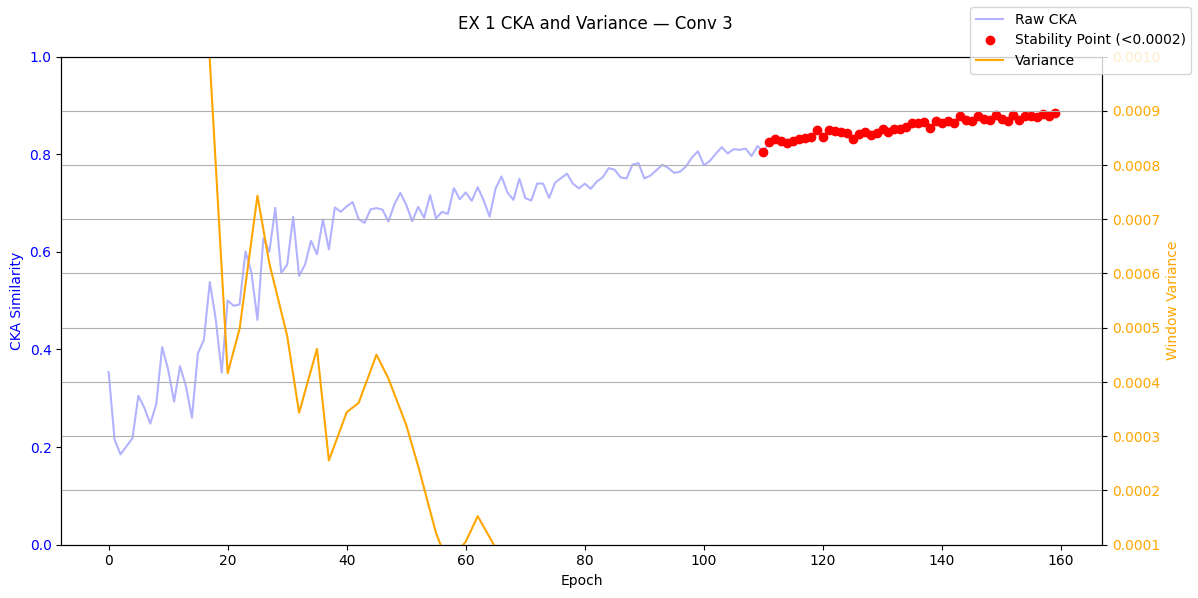

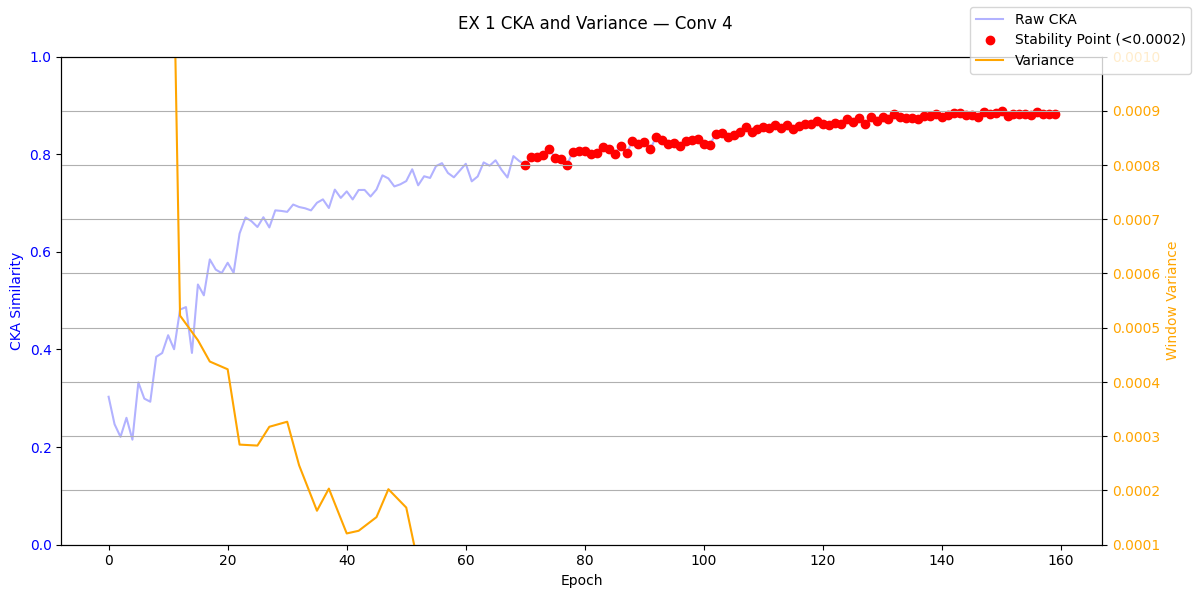

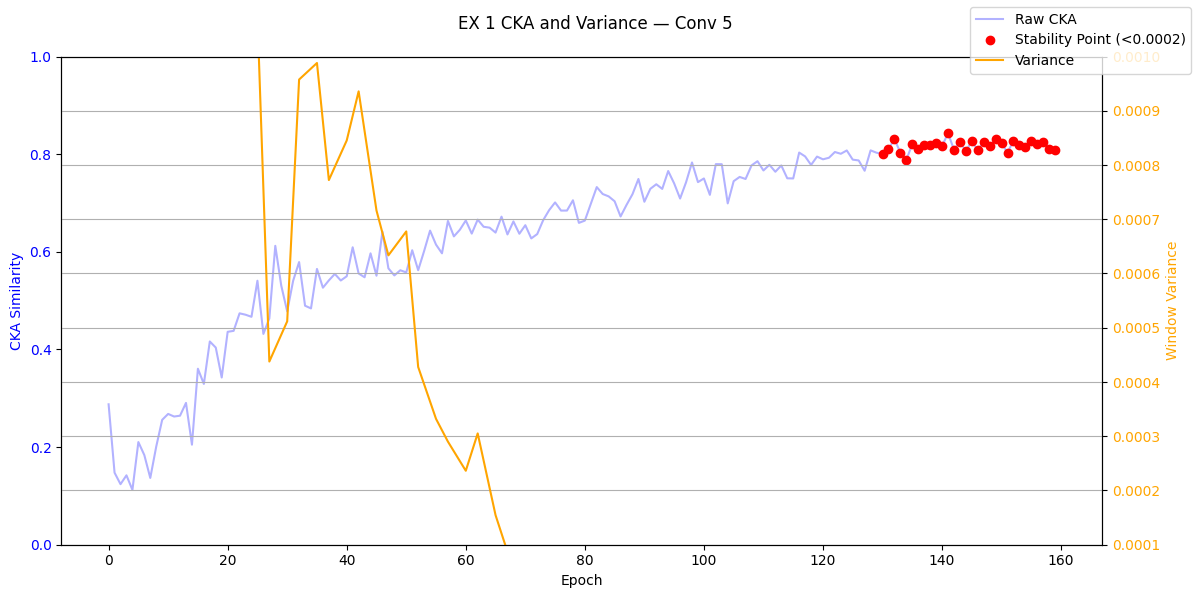

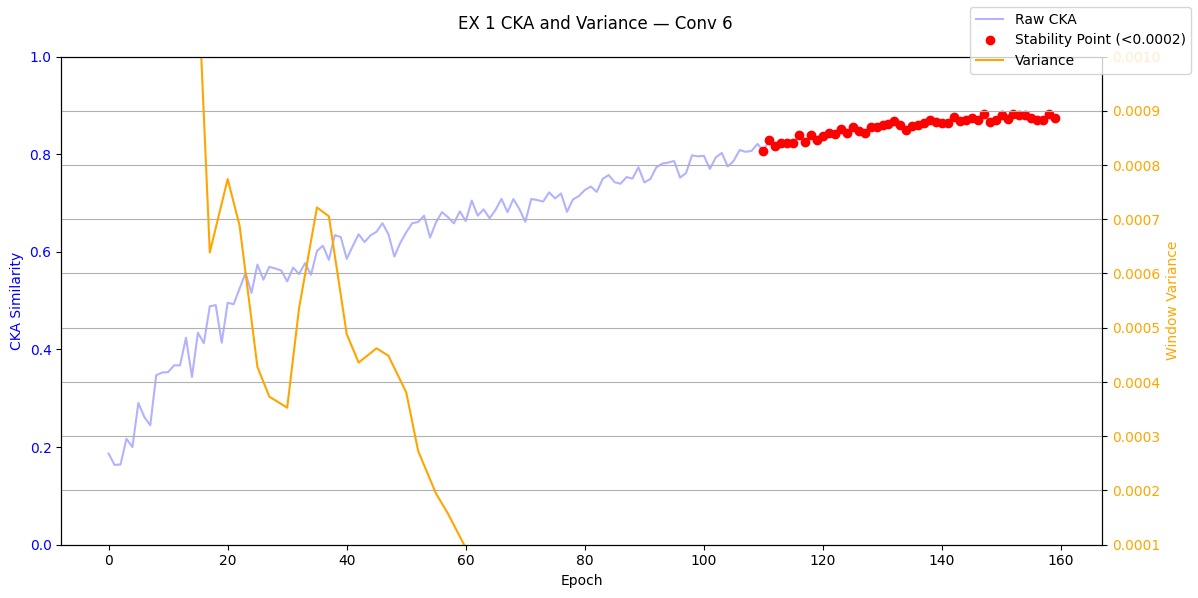

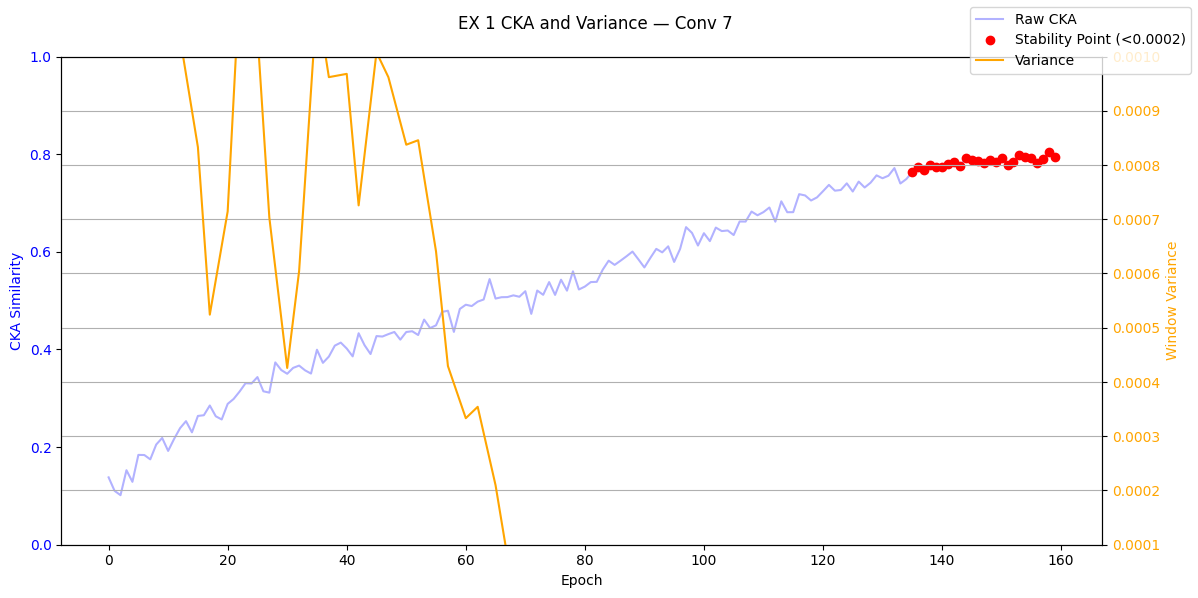

In [119]:
import numpy as np
import matplotlib.pyplot as plt
def get_all_stability_points_for_all_layers(
    all_epochs_matrix, conv_indices, moving_window=20, stride=5, stability_threshold=0.0002, layers=None
):
    if layers is not None:
      cka_freeze_configuration = {layer: [] for layer in layers}
    num_epochs = all_epochs_matrix.shape[0]

    for conv_idx in conv_indices:
        cka_vals = all_epochs_matrix[:, conv_idx]
        if hasattr(cka_vals, 'cpu'):
            cka_vals = cka_vals.cpu().numpy()

        cka_window_values = []
        variance_values = []   # Store variance for plotting
        variance_epochs = []   # Track the center of the window for plotting

        prev_decision_was_frozen = False
        prev_CKA_at_decision_for_frozen = None

        for epoch, cka_val in enumerate(cka_vals):
            cka_window_values.append(cka_val)

            if len(cka_window_values) > moving_window:
                cka_window_values = cka_window_values[stride:]

            if len(cka_window_values) == moving_window:
                window_variance = np.var(cka_window_values, ddof=1)

                center_epoch = (epoch - moving_window + 1) // 2
                start_of_epoch = epoch - moving_window + 1
                # print(f"The Current Epoch: {epoch}, Start of Epoch: {epoch} - {moving_window} = {start_of_epoch}")
                variance_values.append(window_variance)
                variance_epochs.append(center_epoch)
                # After the initial freeze decision, make it so that all labels subsequently are of a frozen layer
                # Doesn't make sense to go back and forth with freezing, measure performance difference after. Weights should change slightly anyway
                if window_variance < stability_threshold and cka_val > 0.3 or cka_freeze_configuration[layers[conv_idx]][-1] == 1:
                    # print(f"Layer {conv_idx} — CKA value when freezing: ", cka_val)
                    # print("Variance of window: ", window_variance)
                    cka_freeze_configuration[layers[conv_idx]].append(1) # 1 for frozen layer
                    cka_freeze_configuration[layers[conv_idx]][-moving_window:] = [1] * moving_window # replace last moving_window elements with 1 for frz
                    prev_decision_was_frozen = True
                    prev_CKA_at_decision_for_frozen = cka_val
                else:
                  cka_freeze_configuration[layers[conv_idx]].append(0) # 0 for non-frozen layer
                  prev_decision_was_frozen = False
                  prev_CKA_at_decision_for_frozen = None
            else:
              if prev_decision_was_frozen:
                # Get percent change, has to be a less than 3% change from the CKA value that was previously frozen at
                prev_cka_value_pct_change = abs(prev_CKA_at_decision_for_frozen - cka_val) / prev_CKA_at_decision_for_frozen
                if prev_cka_value_pct_change < 0.1:
                  cka_freeze_configuration[layers[conv_idx]].append(1) # following previous decision of layer freezing
                else:
                  print("GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER")
                  cka_freeze_configuration[layers[conv_idx]].append(0)
              else:
                cka_freeze_configuration[layers[conv_idx]].append(0) # following previous decision of layer freezing, or there haven't been enough epochs for test

        # Plotting
        fig, ax1 = plt.subplots(figsize=(12, 6))

        ax1.plot(cka_vals, label='Raw CKA', color='blue', alpha=0.3)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('CKA Similarity', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_ylim(0, 1.0)

        # Plot variance on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(variance_epochs, variance_values, label='Variance', color='orange')
        ax2.set_ylabel('Window Variance', color='orange')
        ax2.set_ylim(0.0001, 0.001)
        ax2.tick_params(axis='y', labelcolor='orange')

        # Plot the first stability marker if found
        frz_moment = [epoch_index for epoch_index, frz_decision in enumerate(cka_freeze_configuration[layers[conv_idx]]) if frz_decision == 1]
        cka_val_at_frz_moment = [cka_vals[epoch_index] for epoch_index in frz_moment]
        if frz_moment is not None:
            ax1.plot(frz_moment, cka_val_at_frz_moment, 'ro', label=f'Stability Point (<{stability_threshold})')

        fig.suptitle(f'EX 1 CKA and Variance — Conv {conv_idx}')
        fig.tight_layout()
        fig.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    if layers is not None:
      return cka_freeze_configuration
with open(f"{experiment}/seed_{experiment_seed}/cka_freeze_layer_decisions.pkl", "rb") as f:
    cka_freeze_layer_decisions = pickle.load(f)
layers = list(cka_freeze_layer_decisions.keys())
cka_freeze_layer_configuration = get_all_stability_points_for_all_layers(all_epochs_matrix, conv_indices=[i for i in range(8)], layers=layers) 

In [93]:
print(cka_freeze_layer_configuration)

{0: ['features.0', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1]], 1: ['features.3', [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1]], 2: ['features.6', [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1]], 3: ['features.8', [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [94]:
with open(f"{experiment}/seed_{experiment_seed}/frz_predictor_track_conv_frozen.pkl", "rb") as f:
    track_conv_frozen_frz_pred_experiment = pickle.load(f)
for layer_index in track_conv_frozen_frz_pred_experiment.keys():
    layer_info = track_conv_frozen_frz_pred_experiment[layer_index]
    layer_name = layer_info[0]
    mambafrz_preds = layer_info[1]
    mambafrz_preds = layer_info[1] + [layer_info[1][-1]] * (160 - len(mambafrz_preds))
    actual_preds = cka_freeze_layer_configuration[layer_name] if layer_name in cka_freeze_layer_configuration.keys() else None
    if actual_preds == None:
        continue
    epochs = np.arange(1, len(mambafrz_preds) + 1)
    plt.title(f"{experiment_name}, Seed {experiment_seed}, Conv # {layer_index}")
    plt.plot(epochs, mambafrz_preds, label="MambaFRZ Preds")
    plt.plot(epochs, actual_preds, label="Ground-Truth")
    plt.legend()
    plt.savefig(f"output_conv_{layer_index}.jpg")
    plt.show()

In [95]:
print(track_conv_frozen_frz_pred_experiment)

{0: ['features.0', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]], 1: ['features.3', [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1]], 2: ['features.6', [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 3: ['features.8', [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

[17, 104, 104, 153, 153, 161, 161, 161]


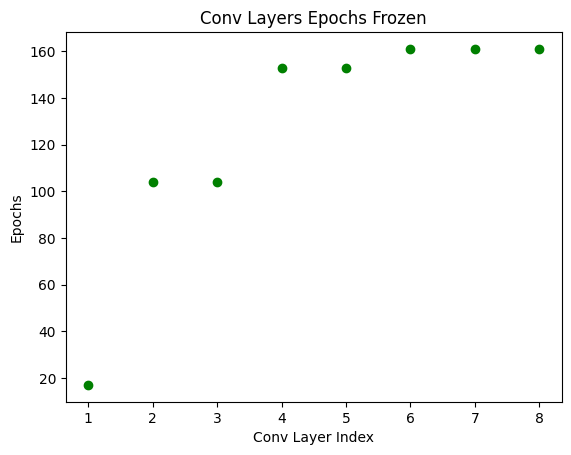

In [96]:
layers = np.arange(1, 9)
epochs_frozen_array = [len(track_conv_frozen_frz_pred_experiment[layer_index-1][1]) + 1 for layer_index in layers]
print(epochs_frozen_array)
plt.title("Conv Layers Epochs Frozen")
plt.xlabel("Conv Layer Index")
plt.ylabel("Epochs")
plt.scatter(layers, epochs_frozen_array, color='green')

## Getting TFLOPs

In [120]:
# Compute FLOPs associated with each layer
def get_flops(model, inp: Union[torch.Tensor, Tuple], with_backward=False):
    istrain = model.training
    model.eval()

    inp = inp if isinstance(inp, torch.Tensor) else torch.randn(inp)

    flop_counter = FlopCounterMode(model, depth=-1, display=False)
    with flop_counter:
        if with_backward:
            model(inp).sum().backward()
        else:
            model(inp)
    layer_flops = flop_counter.get_total_flops()

    if istrain:
        model.train()
    return layer_flops

In [121]:
# CIFAR10
if dataset == "cifar10":
    num_classes = 10
    num_samples_in_test_set = 50000
elif dataset == "cifar100":
    num_classes = 100
    num_samples_in_test_set = 50000
elif dataset == "imagenet":
    num_classes = 1000
    num_samples_in_test_set = 100000
if model_name == "resnet50":
    model = resnet50(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
elif model_name == "vgg11":
    model = vgg11(weights=None)
    num_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_features, num_classes)
elif model_name == "vgg16":
    model = vgg16(weights=None)
    model.features[4] = nn.Identity()
    # Replce first conv with smaller kernel (if desired)
    model.features[0] = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
    num_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_features, num_classes)

In [122]:
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [123]:
input = torch.randn(1, 3, 32, 32)
total_flops_one_input = get_flops(model, input)
total_flops_for_training = num_epochs * (3 * total_flops_one_input * num_samples_in_test_set) / (10 ** 12)
print(f"Full Training: {int(total_flops_for_training)} TFLOPs")

Full Training: 16362 TFLOPs


/tmp/ipykernel_903945/3474023913.py:8: UserWarning:

mods argument is not needed anymore, you can stop passing it



In [124]:
def add_flops_hook(layer_flops):
    def hook(module, input, output):
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            output_shape = output.shape
            if isinstance(module, nn.Conv2d):
                kernel_height, kernel_width = module.kernel_size
                input_channels = module.in_channels
                output_channels = module.out_channels
                output_height, output_width = output_shape[2], output_shape[3]
                flops = (2 * kernel_height * kernel_width * input_channels) * output_channels * output_height * output_width
            elif isinstance(module, nn.Linear):
                input_features = module.in_features
                output_features = module.out_features
                flops = 2 * input_features * output_features
            else:
                flops = 0
                raise ValueError("Should only be looking at FLOPs for FC and Conv!")
            layer_flops[id(module)] = layer_flops.get(id(module), 0) + flops
    return hook
def get_flops(model, inp: Union[torch.Tensor], with_backward=False):
    istrain = model.training
    model.train()

    inp = inp if isinstance(inp, torch.Tensor) else torch.randn(inp)

    layer_flops = {}
    hooks = []
    for name, module in model.named_modules():
        if is_cnn_layer(module):
            hooks.append(module.register_forward_hook(add_flops_hook(layer_flops)))

    # Forward pass
    output = model(inp)

    if with_backward:
        output.sum().backward()

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # Map layer names to FLOPs
    named_flops = {}
    for name, module in model.named_modules():
        if is_cnn_layer(module):
            named_flops[name] = layer_flops.get(id(module), 0)
    # Restore training state
    if istrain:
        model.train()

    return named_flops

In [125]:
conv_and_fc_flops_dict.keys()

dict_keys(['features.0', 'features.3', 'features.6', 'features.8', 'features.11', 'features.13', 'features.16', 'features.18'])

In [126]:
layer_flops = get_flops(model, input)
conv_and_fc_flops_dict = {}
for layer, flops in layer_flops.items():
    conv_and_fc_flops_dict[layer] = flops
print(f"Number of layers for computed FLOPs: {len(conv_and_fc_flops_dict.keys())}")

Number of layers for computed FLOPs: 8


In [127]:
with open(f"{experiment}/seed_{experiment_seed}/frz_predictor_track_conv_frozen.pkl", "rb") as f:
    cka_freeze_layer_configuration = pickle.load(f)
total_flops_for_training = num_epochs * (3 * total_flops_one_input * num_samples_in_test_set)
for epoch in range(num_epochs):
    # Flag for determining if the previous layer was frozen
    is_previous_layer_frozen = False
    for current_layer_index, (layer_name, frz_decisions) in cka_freeze_layer_configuration.items():
        epoch_frozen = len(frz_decisions) # Post-processing window to determine when to freeze
        if epoch >= epoch_frozen:
            total_flops_for_training -= (conv_and_fc_flops_dict[layer_name] * num_samples_in_test_set)
            # First layer never computes backpropagation, cannot remove TFLOPs in that case
            if is_previous_layer_frozen:
                total_flops_for_training -= (conv_and_fc_flops_dict[layer_name] * num_samples_in_test_set)
            is_previous_layer_frozen = True
        else:
            is_previous_layer_frozen = False
print(f"Total FLOPs with Freeze Configuration: {total_flops_for_training / (10 ** 12)} TFLOPs")

Total FLOPs with Freeze Configuration: 14660.5867008 TFLOPs


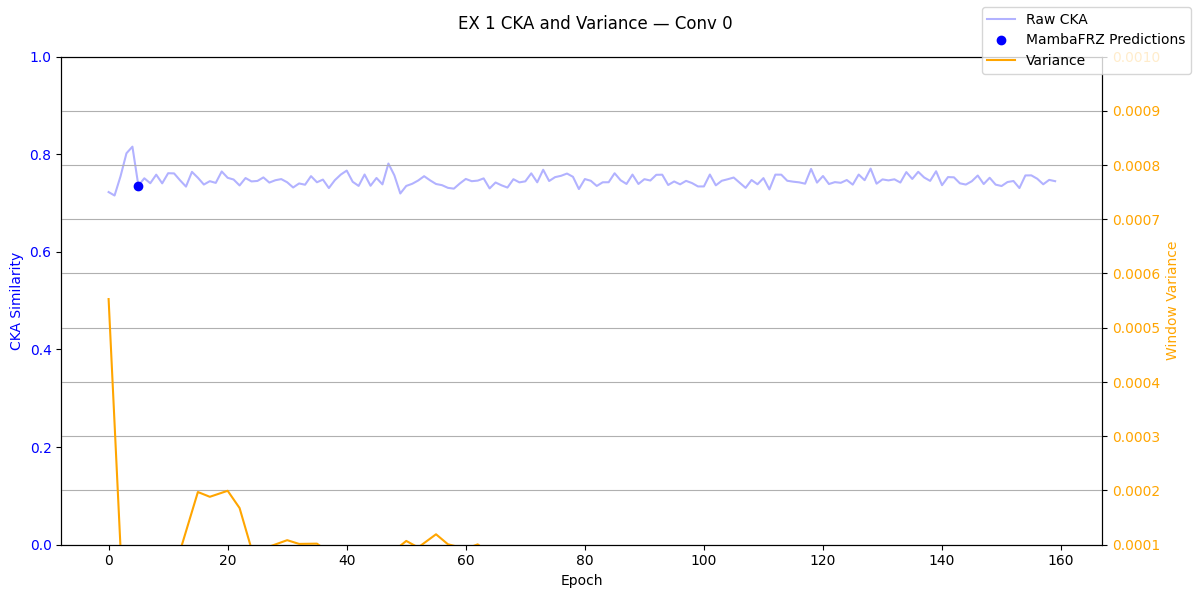

In [11]:
def plot_stability_points_of_all_layers_with_mambafrz_preds(
    all_epochs_matrix, conv_indices, track_conv_frozen_frz_pred=None, moving_window=20, stride=5, stability_threshold=0.0002, layers=None
):
    if layers is not None:
      cka_freeze_configuration = {layer: [] for layer in layers}
    num_epochs = all_epochs_matrix.shape[0]

    for conv_idx in conv_indices:
        cka_vals = all_epochs_matrix[:, conv_idx]
        if hasattr(cka_vals, 'cpu'):
            cka_vals = cka_vals.cpu().numpy()

        cka_window_values = []
        variance_values = []   # Store variance for plotting
        variance_epochs = []   # Track the center of the window for plotting

        prev_decision_was_frozen = False
        prev_CKA_at_decision_for_frozen = None

        for epoch, cka_val in enumerate(cka_vals):
            cka_window_values.append(cka_val)

            if len(cka_window_values) > moving_window:
                cka_window_values = cka_window_values[stride:]

            if len(cka_window_values) == moving_window:
                window_variance = np.var(cka_window_values, ddof=1)

                center_epoch = (epoch - moving_window + 1) // 2
                start_of_epoch = epoch - moving_window + 1
                # print(f"The Current Epoch: {epoch}, Start of Epoch: {epoch} - {moving_window} = {start_of_epoch}")
                variance_values.append(window_variance)
                variance_epochs.append(center_epoch)
                # After the initial freeze decision, make it so that all labels subsequently are of a frozen layer
                # Doesn't make sense to go back and forth with freezing, measure performance difference after. Weights should change slightly anyway
                if window_variance < stability_threshold and cka_val > 0.3 or cka_freeze_configuration[layers[conv_idx]][-1] == 1:
                    # print(f"Layer {conv_idx} — CKA value when freezing: ", cka_val)
                    # print("Variance of window: ", window_variance)
                    cka_freeze_configuration[layers[conv_idx]].append(1) # 1 for frozen layer
                    cka_freeze_configuration[layers[conv_idx]][-moving_window:] = [1] * moving_window # replace last moving_window elements with 1 for frz
                    prev_decision_was_frozen = True
                    prev_CKA_at_decision_for_frozen = cka_val
                else:
                  cka_freeze_configuration[layers[conv_idx]].append(0) # 0 for non-frozen layer
                  prev_decision_was_frozen = False
                  prev_CKA_at_decision_for_frozen = None
            else:
              if prev_decision_was_frozen:
                # Get percent change, has to be a less than 3% change from the CKA value that was previously frozen at
                prev_cka_value_pct_change = abs(prev_CKA_at_decision_for_frozen - cka_val) / prev_CKA_at_decision_for_frozen
                if prev_cka_value_pct_change < 0.1:
                  cka_freeze_configuration[layers[conv_idx]].append(1) # following previous decision of layer freezing
                else:
                  print("GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER")
                  cka_freeze_configuration[layers[conv_idx]].append(0)
              else:
                cka_freeze_configuration[layers[conv_idx]].append(0) # following previous decision of layer freezing, or there haven't been enough epochs for test

        # Plotting
        fig, ax1 = plt.subplots(figsize=(12, 6))

        ax1.plot(cka_vals, label='Raw CKA', color='blue', alpha=0.3)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('CKA Similarity', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_ylim(0, 1.0)

        # Plot variance on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(variance_epochs, variance_values, label='Variance', color='orange')
        ax2.set_ylabel('Window Variance', color='orange')
        ax2.set_ylim(0.0001, 0.001)
        ax2.tick_params(axis='y', labelcolor='orange')

        # Plot the first stability marker if found
        frz_moment = [epoch_index for epoch_index, frz_decision in enumerate(cka_freeze_configuration[layers[conv_idx]]) if frz_decision == 1]
        cka_val_at_frz_moment = [cka_vals[epoch_index] for epoch_index in frz_moment]
        
        # Plot the predictions by MambaFRZ
        frz_moment_2 = [epoch_index for epoch_index, frz_decision in enumerate(track_conv_frozen_frz_pred[conv_idx][1]) if frz_decision == 1]
        cka_val_at_frz_moment_2 = [cka_vals[epoch_index] for epoch_index in frz_moment_2]
        
        # if frz_moment is not None:
        #     ax1.plot(frz_moment, cka_val_at_frz_moment, 'ro', label=f'Stability Point (<{stability_threshold})')
        
        if frz_moment_2 is not None:
            ax1.plot(frz_moment_2, cka_val_at_frz_moment_2, 'bo', label=f"MambaFRZ Predictions")

        fig.suptitle(f'EX 1 CKA and Variance — Conv {conv_idx}')
        fig.tight_layout()
        fig.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    if layers is not None:
      return cka_freeze_configuration
with open(f"{experiment}/seed_{experiment_seed}/cka_freeze_layer_decisions.pkl", "rb") as f:
    cka_freeze_layer_decisions = pickle.load(f)
layers = list(cka_freeze_layer_decisions.keys())
cka_freeze_layer_configuration = plot_stability_points_of_all_layers_with_mambafrz_preds(all_epochs_matrix, conv_indices=[i for i in range(1)], layers=layers, track_conv_frozen_frz_pred=track_conv_frozen_frz_pred_experiment) 